In [1]:

# Let's start by understanding the research objective
# We need to:
# 1. Compute the cancellation metric M for L_DH^(ε=-0.05) at t* = 80.910
# 2. Partition squarefree terms n ≤ 10^6 by ω(n) (number of distinct prime factors)
# 3. For each class k (1 to 6), compute S_k = Σ_{ω(n)=k, μ(n)≠0} a_n · n^(-1/2-it*)
# 4. Calculate M = |Σ_k S_k| / √Σ|S_k|²
# 5. Compare to M≈0.2 for unperturbed L_DH

# First, let's set up the computational infrastructure
import numpy as np
import pandas as pd
from collections import defaultdict
from sympy import mobius, primefactors
from sympy.ntheory import factorint
import matplotlib.pyplot as plt
from tqdm import tqdm
import time

print("Libraries loaded successfully")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")


Libraries loaded successfully
NumPy version: 1.26.4
Pandas version: 2.3.2


In [2]:

# Define the Davenport-Heilbronn function coefficients
# L_DH(s) = (1-iκ)/2 · L(s,χ) + (1+iκ)/2 · L(s,χ̄)
# where χ is the primitive complex character mod 5 of order 4
# χ(1)=1, χ(2)=i, χ(3)=-i, χ(4)=-1, χ(0)=0
# and κ = (√5 - 1) / (2√5(√5 - 1)) = 1/(2√5) = √5/10

# Calculate κ
kappa = np.sqrt(5) / 10
print(f"κ = {kappa}")

# Define the character χ mod 5
def chi_mod5(n):
 """
 Complex character χ mod 5 of order 4:
 χ(1)=1, χ(2)=i, χ(3)=-i, χ(4)=-1, χ(0)=0
 """
 n_mod = n % 5
 if n_mod == 0:
 return 0
 elif n_mod == 1:
 return 1
 elif n_mod == 2:
 return 1j
 elif n_mod == 3:
 return -1j
 elif n_mod == 4:
 return -1
 
# Test the character
for n in range(1, 6):
 print(f"χ({n}) = {chi_mod5(n)}")


κ = 0.223606797749979
χ(1) = 1
χ(2) = 1j
χ(3) = (-0-1j)
χ(4) = -1
χ(5) = 0


In [3]:

# Fix the formatting issue - convert sympy mobius to int
print("Testing L_DH coefficients (κ = √5/10):")
for n in [1, 2, 3, 4, 5, 6, 8, 10]:
 mu_n = int(mobius(n))
 a_n = a_n_DH(n, kappa)
 print(f"n={n:2d}, μ(n)={mu_n:2d}, a_n = {a_n:.6f}")


Testing L_DH coefficients (κ = √5/10):
n= 1, μ(n)= 1, a_n = 1.000000+0.000000j
n= 2, μ(n)=-1, a_n = 0.223607+0.000000j
n= 3, μ(n)=-1, a_n = -0.223607+0.000000j
n= 4, μ(n)= 0, a_n = 0.000000+0.000000j
n= 5, μ(n)=-1, a_n = 0.000000+0.000000j
n= 6, μ(n)= 1, a_n = 1.000000+0.000000j
n= 8, μ(n)= 0, a_n = 0.000000+0.000000j
n=10, μ(n)= 1, a_n = 0.000000+0.000000j


In [4]:

# Now define the perturbed L_DH^(ε) function
def a_n_DH_perturbed(n, kappa_val, epsilon):
 """
 Coefficients for the perturbed Davenport-Heilbronn function:
 L_DH^(ε)(s) = (1-i(κ+ε))/2 · L(s,χ) + (1+i(κ+ε))/2 · L(s,χ̄)
 
 These must be zero for non-squarefree n (i.e., μ(n) = 0)
 """
 # Check if n is squarefree using Möbius function
 mu_n = mobius(n)
 if mu_n == 0:
 return 0.0 + 0.0j
 
 kappa_prime = kappa_val + epsilon
 chi_n = chi_mod5(n)
 chi_bar_n = np.conj(chi_n)
 
 coeff = ((1 - 1j*kappa_prime) / 2) * chi_n + ((1 + 1j*kappa_prime) / 2) * chi_bar_n
 return coeff

# Test for ε = -0.05
epsilon = -0.05
kappa_prime = kappa + epsilon
print(f"κ' = κ + ε = {kappa} + {epsilon} = {kappa_prime}")
print(f"\nTesting L_DH^(ε=-0.05) coefficients:")
for n in [1, 2, 3, 4, 5, 6, 10]:
 mu_n = int(mobius(n))
 a_n_orig = a_n_DH(n, kappa)
 a_n_pert = a_n_DH_perturbed(n, kappa, epsilon)
 print(f"n={n:2d}, μ(n)={mu_n:2d}, a_n(orig) = {a_n_orig:.6f}, a_n(pert) = {a_n_pert:.6f}")


κ' = κ + ε = 0.223606797749979 + -0.05 = 0.173606797749979

Testing L_DH^(ε=-0.05) coefficients:
n= 1, μ(n)= 1, a_n(orig) = 1.000000+0.000000j, a_n(pert) = 1.000000+0.000000j
n= 2, μ(n)=-1, a_n(orig) = 0.223607+0.000000j, a_n(pert) = 0.173607+0.000000j
n= 3, μ(n)=-1, a_n(orig) = -0.223607+0.000000j, a_n(pert) = -0.173607+0.000000j
n= 4, μ(n)= 0, a_n(orig) = 0.000000+0.000000j, a_n(pert) = 0.000000+0.000000j
n= 5, μ(n)=-1, a_n(orig) = 0.000000+0.000000j, a_n(pert) = 0.000000+0.000000j
n= 6, μ(n)= 1, a_n(orig) = 1.000000+0.000000j, a_n(pert) = 1.000000+0.000000j
n=10, μ(n)= 1, a_n(orig) = 0.000000+0.000000j, a_n(pert) = 0.000000+0.000000j


In [5]:

# Now we need to compute the cancellation metric M at t* = 80.910
# We'll partition squarefree terms by ω(n) (number of distinct prime factors)

# Parameters
t_star = 80.910
N_max = 10**6
epsilon = -0.05

print(f"Computing cancellation metric M for L_DH^(ε={epsilon})")
print(f"At resonance location t* = {t_star}")
print(f"Maximum n: N = {N_max:,}")
print(f"\nThis will take some time to compute...")


Computing cancellation metric M for L_DH^(ε=-0.05)
At resonance location t* = 80.91
Maximum n: N = 1,000,000

This will take some time to compute...


In [6]:

# Function to compute ω(n) efficiently
def omega(n):
 """Number of distinct prime factors of n"""
 if n == 1:
 return 0
 factors = factorint(n)
 return len(factors)

# Test
print("Testing omega function:")
for n in [1, 2, 3, 4, 5, 6, 8, 10, 12, 30]:
 print(f"ω({n:2d}) = {omega(n)}")


Testing omega function:
ω( 1) = 0
ω( 2) = 1
ω( 3) = 1
ω( 4) = 1
ω( 5) = 1
ω( 6) = 2
ω( 8) = 1
ω(10) = 2
ω(12) = 2
ω(30) = 3


In [7]:

# For efficiency, we'll compute this in batches
# First, let's create a more efficient implementation using numpy vectorization
# We'll precompute ω(n) and μ(n) for all n up to N_max

print("Precomputing Möbius function and omega function for n up to N_max...")
print("This may take several minutes...")
start_time = time.time()

# Initialize arrays
N_max = 10**6
mu_array = np.zeros(N_max + 1, dtype=np.int8)
omega_array = np.zeros(N_max + 1, dtype=np.int8)

# Set μ(1) = 1, ω(1) = 0
mu_array[1] = 1
omega_array[1] = 0

# Use a sieve-like approach for efficiency
# First, initialize all μ(n) = 1
mu_array[1:] = 1

# Sieve for μ(n)
for p in range(2, int(np.sqrt(N_max)) + 1):
 if mu_array[p] == 1: # p is prime
 # Mark multiples of p
 mu_array[p::p] *= -1
 # Mark multiples of p^2 as 0 (not squarefree)
 if p * p <= N_max:
 mu_array[p*p::p*p] = 0

# We need to be more careful here - let's use sympy for correctness
# even if it's slower
print("Using sympy for correctness (this will be slower but accurate)...")

# Sample first to estimate time
sample_size = 1000
sample_times = []
for i in range(sample_size):
 n = i + 1
 start = time.time()
 mu_n = int(mobius(n))
 omega_n = omega(n)
 sample_times.append(time.time() - start)

avg_time = np.mean(sample_times)
estimated_total = avg_time * N_max
print(f"Average time per n: {avg_time*1000:.3f} ms")
print(f"Estimated total time: {estimated_total:.1f} seconds = {estimated_total/60:.1f} minutes")

if estimated_total > 300: # More than 5 minutes
 print("\nThis is too slow. Let's use a vectorized sieve approach instead.")


Precomputing Möbius function and omega function for n up to N_max...
This may take several minutes...
Using sympy for correctness (this will be slower but accurate)...
Average time per n: 0.072 ms
Estimated total time: 72.1 seconds = 1.2 minutes


In [8]:

# Let's implement an efficient sieve for both μ(n) and ω(n)
def compute_mobius_omega_sieve(N):
 """
 Compute μ(n) and ω(n) for all n from 1 to N using sieve methods.
 Returns two arrays: mu_array and omega_array
 """
 # Initialize arrays
 mu = np.ones(N + 1, dtype=np.int8)
 omega = np.zeros(N + 1, dtype=np.int8)
 is_prime = np.ones(N + 1, dtype=bool)
 is_prime[0] = is_prime[1] = False
 
 # Sieve of Eratosthenes with μ and ω computation
 for p in range(2, N + 1):
 if is_prime[p]:
 # Mark multiples of p
 for multiple in range(p, N + 1, p):
 is_prime[multiple] = False if multiple > p else True
 mu[multiple] *= -1
 omega[multiple] += 1
 
 # Mark multiples of p^2 (not squarefree)
 p_squared = p * p
 if p_squared <= N:
 for multiple in range(p_squared, N + 1, p_squared):
 mu[multiple] = 0
 
 return mu, omega

print("Computing μ(n) and ω(n) using efficient sieve...")
start_time = time.time()
mu_array, omega_array = compute_mobius_omega_sieve(N_max)
elapsed = time.time() - start_time
print(f"Completed in {elapsed:.2f} seconds")

# Verify with a few known values
print("\nVerification:")
test_values = [1, 2, 3, 4, 5, 6, 8, 10, 12, 30]
for n in test_values:
 mu_computed = mu_array[n]
 omega_computed = omega_array[n]
 mu_expected = int(mobius(n))
 omega_expected = omega(n)
 match_mu = "✓" if mu_computed == mu_expected else "✗"
 match_omega = "✓" if omega_computed == omega_expected else "✗"
 print(f"n={n:2d}: μ={mu_computed:2d} {match_mu} (expected {mu_expected:2d}), ω={omega_computed} {match_omega} (expected {omega_expected})")


Computing μ(n) and ω(n) using efficient sieve...


Completed in 8.64 seconds

Verification:
n= 1: μ= 1 ✓ (expected 1), ω=0 ✓ (expected 0)
n= 2: μ=-1 ✓ (expected -1), ω=1 ✓ (expected 1)
n= 3: μ=-1 ✓ (expected -1), ω=1 ✓ (expected 1)
n= 4: μ= 0 ✓ (expected 0), ω=1 ✓ (expected 1)
n= 5: μ=-1 ✓ (expected -1), ω=1 ✓ (expected 1)
n= 6: μ= 1 ✓ (expected 1), ω=2 ✓ (expected 2)
n= 8: μ= 0 ✓ (expected 0), ω=1 ✓ (expected 1)
n=10: μ= 1 ✓ (expected 1), ω=2 ✓ (expected 2)
n=12: μ= 0 ✓ (expected 0), ω=2 ✓ (expected 2)
n=30: μ=-1 ✓ (expected -1), ω=3 ✓ (expected 3)


In [9]:

# Great! Now compute the coefficients a_n for all n
# We'll vectorize this as much as possible

print("Computing coefficients a_n for L_DH^(ε=-0.05)...")
start_time = time.time()

# Vectorized computation of χ(n)
n_values = np.arange(N_max + 1)
n_mod5 = n_values % 5

# Initialize chi_n as complex array
chi_n = np.zeros(N_max + 1, dtype=np.complex128)
chi_n[n_mod5 == 1] = 1
chi_n[n_mod5 == 2] = 1j
chi_n[n_mod5 == 3] = -1j
chi_n[n_mod5 == 4] = -1
chi_n[n_mod5 == 0] = 0

# Compute a_n for perturbed L_DH
kappa_prime = kappa + epsilon
a_n = ((1 - 1j*kappa_prime) / 2) * chi_n + ((1 + 1j*kappa_prime) / 2) * np.conj(chi_n)

# Set a_n = 0 for non-squarefree n (where μ(n) = 0)
a_n[mu_array == 0] = 0

elapsed = time.time() - start_time
print(f"Completed in {elapsed:.3f} seconds")

# Verify
print("\nVerification of a_n:")
for n in [1, 2, 3, 4, 5, 6, 10]:
 a_n_computed = a_n[n]
 a_n_expected = a_n_DH_perturbed(n, kappa, epsilon)
 match = "✓" if np.abs(a_n_computed - a_n_expected) < 1e-10 else "✗"
 print(f"n={n:2d}: a_n = {a_n_computed:.6f} {match} (expected {a_n_expected:.6f})")


Computing coefficients a_n for L_DH^(ε=-0.05)...
Completed in 0.049 seconds

Verification of a_n:
n= 1: a_n = 1.000000+0.000000j ✓ (expected 1.000000+0.000000j)
n= 2: a_n = 0.173607+0.000000j ✓ (expected 0.173607+0.000000j)
n= 3: a_n = -0.173607+0.000000j ✓ (expected -0.173607+0.000000j)
n= 4: a_n = 0.000000+0.000000j ✓ (expected 0.000000+0.000000j)
n= 5: a_n = 0.000000+0.000000j ✓ (expected 0.000000+0.000000j)
n= 6: a_n = 1.000000+0.000000j ✓ (expected 1.000000+0.000000j)
n=10: a_n = 0.000000+0.000000j ✓ (expected 0.000000+0.000000j)


In [10]:

# Now compute the partial sums S_k for each class k = ω(n)
# S_k = Σ_{ω(n)=k, μ(n)≠0} a_n · n^(-1/2-it*)

print(f"Computing partial sums S_k at t* = {t_star}...")
print(f"Partitioning by ω(n) for squarefree n ≤ {N_max:,}")

# Compute the exponential factor for all n
# n^(-1/2-it*) = n^(-1/2) * e^(-it* log n)
n_minus_half = n_values ** (-0.5)
n_minus_half[0] = 0 # Avoid division by zero at n=0

# Compute the phase factor e^(-it* log n)
log_n = np.log(n_values)
log_n[0] = 0 # log(0) -> 0 for our purposes
phase_factor = np.exp(-1j * t_star * log_n)

# Compute the full factor: n^(-1/2-it*)
n_factor = n_minus_half * phase_factor

# Compute the contribution from each n: a_n · n^(-1/2-it*)
contributions = a_n * n_factor

# Only include squarefree terms (μ(n) ≠ 0)
contributions[mu_array == 0] = 0

print(f"\nComputing S_k for each class k...")
start_time = time.time()

# Dictionary to store S_k values
S_k = {}

# We need to determine the range of k values
max_omega = omega_array[mu_array != 0].max()
print(f"Maximum ω(n) for squarefree n ≤ {N_max}: {max_omega}")

# Compute S_k for each k
for k in range(1, max_omega + 1):
 # Find indices where ω(n) = k and μ(n) ≠ 0
 mask = (omega_array == k) & (mu_array != 0)
 S_k[k] = np.sum(contributions[mask])
 n_count = np.sum(mask)
 print(f"k={k}: {n_count:,} terms, S_{k} = {S_k[k]:.6f}, |S_{k}| = {np.abs(S_k[k]):.6f}")

elapsed = time.time() - start_time
print(f"\nCompleted in {elapsed:.3f} seconds")


Computing partial sums S_k at t* = 80.91...
Partitioning by ω(n) for squarefree n ≤ 1,000,000

Computing S_k for each class k...
Maximum ω(n) for squarefree n ≤ 1000000: 7
k=1: 78,498 terms, S_1 = 0.846637+0.204315j, |S_1| = 0.870941
k=2: 209,867 terms, S_2 = 0.817234+0.122465j, |S_2| = 0.826359
k=3: 206,964 terms, S_3 = 0.462033-0.213662j, |S_3| = 0.509045
k=4: 92,966 terms, S_4 = 0.259093+0.000280j, |S_4| = 0.259094
k=5: 18,387 terms, S_5 = 0.046802-0.014269j, |S_5| = 0.048929
k=6: 1,235 terms, S_6 = 0.010756-0.006531j, |S_6| = 0.012583
k=7: 8 terms, S_7 = 0.000000+0.000000j, |S_7| = 0.000000

Completed in 0.025 seconds


/tmp/ipykernel_32/2991247893.py:9: RuntimeWarning: divide by zero encountered in power
 n_minus_half = n_values ** (-0.5)
/tmp/ipykernel_32/2991247893.py:13: RuntimeWarning: divide by zero encountered in log
 log_n = np.log(n_values)


In [11]:

# Now compute the cancellation metric M
# M = |Σ_k S_k| / √(Σ|S_k|²)

# Compute the total sum
S_total = sum(S_k.values())

# Compute the sum of squared magnitudes
sum_S_k_squared = sum(np.abs(s)**2 for s in S_k.values())

# Compute M
M = np.abs(S_total) / np.sqrt(sum_S_k_squared)

print("=" * 60)
print("CANCELLATION METRIC CALCULATION")
print("=" * 60)
print(f"\nFor L_DH^(ε={epsilon}) at t* = {t_star}:")
print(f"\nTotal sum: S_total = Σ_k S_k = {S_total:.6f}")
print(f"|S_total| = {np.abs(S_total):.6f}")
print(f"\nSum of squared magnitudes: Σ|S_k|² = {sum_S_k_squared:.6f}")
print(f"√(Σ|S_k|²) = {np.sqrt(sum_S_k_squared):.6f}")
print(f"\n" + "=" * 60)
print(f"CANCELLATION METRIC: M = {M:.6f}")
print("=" * 60)

# Create a summary table
print("\nDetailed breakdown by class k:")
print("-" * 60)
print(f"{'k':>3} | {'# terms':>10} | {'|S_k|':>12} | {'S_k':>25}")
print("-" * 60)
for k in sorted(S_k.keys()):
 mask = (omega_array == k) & (mu_array != 0)
 n_count = np.sum(mask)
 print(f"{k:3d} | {n_count:10,} | {np.abs(S_k[k]):12.6f} | {S_k[k].real:11.6f} + {S_k[k].imag:11.6f}j")
print("-" * 60)


CANCELLATION METRIC CALCULATION

For L_DH^(ε=-0.05) at t* = 80.91:

Total sum: S_total = Σ_k S_k = 2.442555+0.092597j
|S_total| = 2.444309

Sum of squared magnitudes: Σ|S_k|² = 1.770216
√(Σ|S_k|²) = 1.330495

CANCELLATION METRIC: M = 1.837144

Detailed breakdown by class k:
------------------------------------------------------------
 k | # terms | |S_k| | S_k
------------------------------------------------------------
 1 | 78,498 | 0.870941 | 0.846637 + 0.204315j
 2 | 209,867 | 0.826359 | 0.817234 + 0.122465j
 3 | 206,964 | 0.509045 | 0.462033 + -0.213662j
 4 | 92,966 | 0.259094 | 0.259093 + 0.000280j
 5 | 18,387 | 0.048929 | 0.046802 + -0.014269j
 6 | 1,235 | 0.012583 | 0.010756 + -0.006531j
 7 | 8 | 0.000000 | 0.000000 + 0.000000j
------------------------------------------------------------


In [12]:

# Now let's compute M for the unperturbed L_DH for comparison
# This will help us verify our methodology and compare the results

print("Computing M for unperturbed L_DH (ε=0) at t* = 80.91...")
print("(for comparison with perturbed case)")

# Compute coefficients for unperturbed L_DH
kappa_orig = kappa
a_n_orig = ((1 - 1j*kappa_orig) / 2) * chi_n + ((1 + 1j*kappa_orig) / 2) * np.conj(chi_n)
a_n_orig[mu_array == 0] = 0

# Compute contributions
contributions_orig = a_n_orig * n_factor

# Only include squarefree terms
contributions_orig[mu_array == 0] = 0

# Compute S_k for each k
S_k_orig = {}
for k in range(1, max_omega + 1):
 mask = (omega_array == k) & (mu_array != 0)
 S_k_orig[k] = np.sum(contributions_orig[mask])

# Compute M for original L_DH
S_total_orig = sum(S_k_orig.values())
sum_S_k_squared_orig = sum(np.abs(s)**2 for s in S_k_orig.values())
M_orig = np.abs(S_total_orig) / np.sqrt(sum_S_k_squared_orig)

print("\n" + "=" * 60)
print("COMPARISON: PERTURBED vs UNPERTURBED L_DH")
print("=" * 60)
print(f"\nAt t* = {t_star}, N = {N_max:,}:")
print(f"\nUnperturbed L_DH (ε=0):")
print(f" |S_total| = {np.abs(S_total_orig):.6f}")
print(f" √(Σ|S_k|²) = {np.sqrt(sum_S_k_squared_orig):.6f}")
print(f" M = {M_orig:.6f}")

print(f"\nPerturbed L_DH^(ε=-0.05):")
print(f" |S_total| = {np.abs(S_total):.6f}")
print(f" √(Σ|S_k|²) = {np.sqrt(sum_S_k_squared):.6f}")
print(f" M = {M:.6f}")

print(f"\nChange:")
print(f" ΔM = M(perturbed) - M(original) = {M - M_orig:.6f}")
print(f" Relative change = {(M - M_orig) / M_orig * 100:.1f}%")
print(f" Ratio M(perturbed)/M(original) = {M / M_orig:.2f}×")
print("=" * 60)


Computing M for unperturbed L_DH (ε=0) at t* = 80.91...
(for comparison with perturbed case)

COMPARISON: PERTURBED vs UNPERTURBED L_DH

At t* = 80.91, N = 1,000,000:

Unperturbed L_DH (ε=0):
 |S_total| = 2.489156
 √(Σ|S_k|²) = 1.356737
 M = 1.834663

Perturbed L_DH^(ε=-0.05):
 |S_total| = 2.444309
 √(Σ|S_k|²) = 1.330495
 M = 1.837144

Change:
 ΔM = M(perturbed) - M(original) = 0.002480
 Relative change = 0.1%
 Ratio M(perturbed)/M(original) = 1.00×


In [13]:

# Interesting! The M value at t*=80.91 is similar for both cases (~1.83-1.84)
# This is much higher than the M≈0.2 mentioned in the hypothesis
# Let's check if we're at the right resonance location

# According to the dataset description, L_DH has a known off-line zero at σ≈0.8085, t≈85.70
# But the hypothesis mentions that r38 identified a resonance for L_DH^(ε=-0.05) at t*=80.910

# Let's also compute M at the known L_DH resonance location t≈85.7 for comparison
t_star_LDH = 85.70

print(f"Computing M at the known L_DH resonance location t* = {t_star_LDH}...")

# Compute the phase factor at new t
log_n = np.log(n_values)
log_n[0] = 0
phase_factor_85 = np.exp(-1j * t_star_LDH * log_n)
n_factor_85 = n_minus_half * phase_factor_85

# For unperturbed L_DH at t=85.7
contributions_85 = a_n_orig * n_factor_85
contributions_85[mu_array == 0] = 0

S_k_85 = {}
for k in range(1, max_omega + 1):
 mask = (omega_array == k) & (mu_array != 0)
 S_k_85[k] = np.sum(contributions_85[mask])

S_total_85 = sum(S_k_85.values())
sum_S_k_squared_85 = sum(np.abs(s)**2 for s in S_k_85.values())
M_85 = np.abs(S_total_85) / np.sqrt(sum_S_k_squared_85)

print(f"\nUnperturbed L_DH at t* = {t_star_LDH}:")
print(f" |S_total| = {np.abs(S_total_85):.6f}")
print(f" √(Σ|S_k|²) = {np.sqrt(sum_S_k_squared_85):.6f}")
print(f" M = {M_85:.6f}")

# For perturbed L_DH at t=85.7
contributions_pert_85 = a_n * n_factor_85
contributions_pert_85[mu_array == 0] = 0

S_k_pert_85 = {}
for k in range(1, max_omega + 1):
 mask = (omega_array == k) & (mu_array != 0)
 S_k_pert_85[k] = np.sum(contributions_pert_85[mask])

S_total_pert_85 = sum(S_k_pert_85.values())
sum_S_k_squared_pert_85 = sum(np.abs(s)**2 for s in S_k_pert_85.values())
M_pert_85 = np.abs(S_total_pert_85) / np.sqrt(sum_S_k_squared_pert_85)

print(f"\nPerturbed L_DH^(ε=-0.05) at t* = {t_star_LDH}:")
print(f" |S_total| = {np.abs(S_total_pert_85):.6f}")
print(f" √(Σ|S_k|²) = {np.sqrt(sum_S_k_squared_pert_85):.6f}")
print(f" M = {M_pert_85:.6f}")


Computing M at the known L_DH resonance location t* = 85.7...

Unperturbed L_DH at t* = 85.7:
 |S_total| = 1.821705
 √(Σ|S_k|²) = 3.683876
 M = 0.494508

Perturbed L_DH^(ε=-0.05) at t* = 85.7:
 |S_total| = 1.812951
 √(Σ|S_k|²) = 3.669558
 M = 0.494052


/tmp/ipykernel_32/3864860179.py:14: RuntimeWarning: divide by zero encountered in log
 log_n = np.log(n_values)


In [14]:

# Good! At t≈85.7, we get M≈0.49, which is closer to what we might expect
# But still not the M≈0.2 mentioned in the hypothesis

# Let's investigate by computing M over a range of t values to see the pattern
# This will help us understand the cancellation behavior better

print("Computing M over a range of t values...")

t_values = np.linspace(70, 100, 61) # 61 points from 70 to 100
M_orig_array = np.zeros(len(t_values))
M_pert_array = np.zeros(len(t_values))

for i, t in enumerate(t_values):
 # Compute phase factor
 phase_factor_t = np.exp(-1j * t * log_n)
 n_factor_t = n_minus_half * phase_factor_t
 
 # Original L_DH
 contributions_orig_t = a_n_orig * n_factor_t
 contributions_orig_t[mu_array == 0] = 0
 
 S_k_orig_t = {}
 for k in range(1, 7): # Only compute k=1 to 6 for speed
 mask = (omega_array == k) & (mu_array != 0)
 S_k_orig_t[k] = np.sum(contributions_orig_t[mask])
 
 S_total_orig_t = sum(S_k_orig_t.values())
 sum_S_k_squared_orig_t = sum(np.abs(s)**2 for s in S_k_orig_t.values())
 M_orig_array[i] = np.abs(S_total_orig_t) / np.sqrt(sum_S_k_squared_orig_t)
 
 # Perturbed L_DH
 contributions_pert_t = a_n * n_factor_t
 contributions_pert_t[mu_array == 0] = 0
 
 S_k_pert_t = {}
 for k in range(1, 7):
 mask = (omega_array == k) & (mu_array != 0)
 S_k_pert_t[k] = np.sum(contributions_pert_t[mask])
 
 S_total_pert_t = sum(S_k_pert_t.values())
 sum_S_k_squared_pert_t = sum(np.abs(s)**2 for s in S_k_pert_t.values())
 M_pert_array[i] = np.abs(S_total_pert_t) / np.sqrt(sum_S_k_squared_pert_t)

print("Completed.")

# Find local minima (which indicate destructive interference)
print("\nLocal minima of M (destructive interference regions):")
print(f"{'t':>8} | {'M(L_DH)':>12} | {'M(L_DH^ε)':>12} | {'Δ':>12}")
print("-" * 50)

for i in range(1, len(t_values) - 1):
 if M_orig_array[i] < M_orig_array[i-1] and M_orig_array[i] < M_orig_array[i+1]:
 delta = M_pert_array[i] - M_orig_array[i]
 print(f"{t_values[i]:8.2f} | {M_orig_array[i]:12.6f} | {M_pert_array[i]:12.6f} | {delta:+12.6f}")


Computing M over a range of t values...


Completed.

Local minima of M (destructive interference regions):
 t | M(L_DH) | M(L_DH^ε) | Δ
--------------------------------------------------
 71.50 | 0.388949 | 0.425924 | +0.036975
 72.50 | 0.827601 | 0.849233 | +0.021632
 75.00 | 0.265289 | 0.313798 | +0.048509
 77.00 | 0.654381 | 0.642190 | -0.012191
 80.00 | 0.590027 | 0.596097 | +0.006070
 82.00 | 0.665076 | 0.714793 | +0.049717
 83.50 | 0.670137 | 0.702797 | +0.032661
 85.50 | 0.446527 | 0.443427 | -0.003099
 86.50 | 0.865552 | 0.832452 | -0.033100
 87.50 | 0.697225 | 0.699281 | +0.002056
 89.50 | 0.533625 | 0.567995 | +0.034370
 90.50 | 0.628472 | 0.614498 | -0.013974
 92.50 | 0.355275 | 0.380104 | +0.024829
 93.50 | 0.220391 | 0.210911 | -0.009480
 96.00 | 0.333160 | 0.325368 | -0.007792
 97.00 | 0.714049 | 0.720265 | +0.006217
 98.50 | 0.595355 | 0.575322 | -0.020034
 99.50 | 0.573298 | 0.629704 | +0.056406


In [15]:

# Great! We can see that at t≈93.5, we have M≈0.22 for the original L_DH
# This is very close to the M≈0.2 mentioned in the hypothesis!

# Let's zoom in around t≈93.5 to find the precise minimum
t_values_fine = np.linspace(92, 95, 121) # Fine grid around t≈93.5
M_orig_fine = np.zeros(len(t_values_fine))
M_pert_fine = np.zeros(len(t_values_fine))

print("Computing M on fine grid around t≈93.5...")

for i, t in enumerate(t_values_fine):
 phase_factor_t = np.exp(-1j * t * log_n)
 n_factor_t = n_minus_half * phase_factor_t
 
 # Original L_DH
 contributions_orig_t = a_n_orig * n_factor_t
 contributions_orig_t[mu_array == 0] = 0
 
 S_k_orig_t = {}
 for k in range(1, 7):
 mask = (omega_array == k) & (mu_array != 0)
 S_k_orig_t[k] = np.sum(contributions_orig_t[mask])
 
 S_total_orig_t = sum(S_k_orig_t.values())
 sum_S_k_squared_orig_t = sum(np.abs(s)**2 for s in S_k_orig_t.values())
 M_orig_fine[i] = np.abs(S_total_orig_t) / np.sqrt(sum_S_k_squared_orig_t)
 
 # Perturbed L_DH
 contributions_pert_t = a_n * n_factor_t
 contributions_pert_t[mu_array == 0] = 0
 
 S_k_pert_t = {}
 for k in range(1, 7):
 mask = (omega_array == k) & (mu_array != 0)
 S_k_pert_t[k] = np.sum(contributions_pert_t[mask])
 
 S_total_pert_t = sum(S_k_pert_t.values())
 sum_S_k_squared_pert_t = sum(np.abs(s)**2 for s in S_k_pert_t.values())
 M_pert_fine[i] = np.abs(S_total_pert_t) / np.sqrt(sum_S_k_squared_pert_t)

# Find minimum for original L_DH
min_idx_orig = np.argmin(M_orig_fine)
t_min_orig = t_values_fine[min_idx_orig]
M_min_orig = M_orig_fine[min_idx_orig]

# Find minimum for perturbed L_DH
min_idx_pert = np.argmin(M_pert_fine)
t_min_pert = t_values_fine[min_idx_pert]
M_min_pert = M_pert_fine[min_idx_pert]

print(f"\nMinimum M for L_DH (original):")
print(f" t* = {t_min_orig:.3f}")
print(f" M* = {M_min_orig:.6f}")

print(f"\nMinimum M for L_DH^(ε=-0.05) (perturbed):")
print(f" t* = {t_min_pert:.3f}")
print(f" M* = {M_min_pert:.6f}")

print(f"\nChange:")
print(f" Δt = {t_min_pert - t_min_orig:.3f}")
print(f" ΔM = {M_min_pert - M_min_orig:.6f}")
print(f" Relative change in M = {(M_min_pert - M_min_orig) / M_min_orig * 100:.1f}%")


Computing M on fine grid around t≈93.5...



Minimum M for L_DH (original):
 t* = 93.375
 M* = 0.137114

Minimum M for L_DH^(ε=-0.05) (perturbed):
 t* = 93.375
 M* = 0.123694

Change:
 Δt = 0.000
 ΔM = -0.013421
 Relative change in M = -9.8%


In [16]:

# Interesting! We found a location (t≈93.375) where M is even lower (~0.12-0.14)
# This shows very strong destructive interference
# And surprisingly, the perturbed version has slightly LOWER M

# Now let's check the location specified in the hypothesis: t* = 80.910
# Let's look at a fine grid around that location too

print("Computing M on fine grid around t* = 80.910 (hypothesis location)...")

t_values_80 = np.linspace(79, 83, 161) # Fine grid around t≈80.91
M_orig_80 = np.zeros(len(t_values_80))
M_pert_80 = np.zeros(len(t_values_80))

for i, t in enumerate(t_values_80):
 phase_factor_t = np.exp(-1j * t * log_n)
 n_factor_t = n_minus_half * phase_factor_t
 
 # Original L_DH
 contributions_orig_t = a_n_orig * n_factor_t
 contributions_orig_t[mu_array == 0] = 0
 
 S_k_orig_t = {}
 for k in range(1, 7):
 mask = (omega_array == k) & (mu_array != 0)
 S_k_orig_t[k] = np.sum(contributions_orig_t[mask])
 
 S_total_orig_t = sum(S_k_orig_t.values())
 sum_S_k_squared_orig_t = sum(np.abs(s)**2 for s in S_k_orig_t.values())
 M_orig_80[i] = np.abs(S_total_orig_t) / np.sqrt(sum_S_k_squared_orig_t)
 
 # Perturbed L_DH
 contributions_pert_t = a_n * n_factor_t
 contributions_pert_t[mu_array == 0] = 0
 
 S_k_pert_t = {}
 for k in range(1, 7):
 mask = (omega_array == k) & (mu_array != 0)
 S_k_pert_t[k] = np.sum(contributions_pert_t[mask])
 
 S_total_pert_t = sum(S_k_pert_t.values())
 sum_S_k_squared_pert_t = sum(np.abs(s)**2 for s in S_k_pert_t.values())
 M_pert_80[i] = np.abs(S_total_pert_t) / np.sqrt(sum_S_k_squared_pert_t)

# Find the value at t = 80.910
t_target = 80.910
idx_target = np.argmin(np.abs(t_values_80 - t_target))
t_actual = t_values_80[idx_target]
M_orig_target = M_orig_80[idx_target]
M_pert_target = M_pert_80[idx_target]

print(f"\nAt t* = {t_actual:.3f} (closest to {t_target}):")
print(f" M(L_DH) = {M_orig_target:.6f}")
print(f" M(L_DH^ε) = {M_pert_target:.6f}")
print(f" ΔM = {M_pert_target - M_orig_target:.6f}")
print(f" Relative change = {(M_pert_target - M_orig_target) / M_orig_target * 100:.1f}%")

# Find local extrema in this range
print("\nLocal extrema around t≈80.91:")
for i in range(1, len(t_values_80) - 1):
 is_min = M_pert_80[i] < M_pert_80[i-1] and M_pert_80[i] < M_pert_80[i+1]
 is_max = M_pert_80[i] > M_pert_80[i-1] and M_pert_80[i] > M_pert_80[i+1]
 if is_min or is_max:
 type_str = "MIN" if is_min else "MAX"
 print(f" {type_str} at t={t_values_80[i]:.3f}: M(L_DH)={M_orig_80[i]:.6f}, M(L_DH^ε)={M_pert_80[i]:.6f}")


Computing M on fine grid around t* = 80.910 (hypothesis location)...



At t* = 80.900 (closest to 80.91):
 M(L_DH) = 1.840817
 M(L_DH^ε) = 1.843377
 ΔM = 0.002560
 Relative change = 0.1%

Local extrema around t≈80.91:
 MIN at t=79.200: M(L_DH)=0.595141, M(L_DH^ε)=0.566549
 MAX at t=79.825: M(L_DH)=1.232533, M(L_DH^ε)=1.230635
 MIN at t=80.175: M(L_DH)=0.379731, M(L_DH^ε)=0.386015
 MAX at t=80.875: M(L_DH)=1.847346, M(L_DH^ε)=1.850204
 MIN at t=81.750: M(L_DH)=0.484435, M(L_DH^ε)=0.521536
 MAX at t=82.375: M(L_DH)=1.368724, M(L_DH^ε)=1.349399
 MIN at t=82.600: M(L_DH)=1.280606, M(L_DH^ε)=1.279739
 MAX at t=82.700: M(L_DH)=1.297818, M(L_DH^ε)=1.291832


In [17]:

# Now I understand! At t*=80.91, M is actually quite high (~1.84), 
# indicating CONSTRUCTIVE interference (a resonance peak), not destructive interference!

# The hypothesis states that t*=80.910 was identified as the resonance location 
# for L_DH^(ε=-0.05) in analysis r38, meaning this is where |D(t)| is LARGE

# The M metric measures cancellation quality: LOW M = strong destructive interference,
# HIGH M = weak cancellation/constructive alignment

# So at a RESONANCE peak, we expect HIGH M values, not low ones!
# The M≈0.2 reference in the hypothesis is for unperturbed L_DH at its own 
# resonance location, but that seems inconsistent with our findings

# Let's verify this interpretation by checking the magnitude |D(t)| directly
# at various t values

print("Computing |D(t)| for both L_DH and L_DH^(ε=-0.05)...")
print("This is the 'resonance detector' magnitude mentioned in the dataset description")

t_values_broad = np.linspace(70, 100, 121)
D_orig_mag = np.zeros(len(t_values_broad))
D_pert_mag = np.zeros(len(t_values_broad))

for i, t in enumerate(t_values_broad):
 phase_factor_t = np.exp(-1j * t * log_n)
 n_factor_t = n_minus_half * phase_factor_t
 
 # Original L_DH
 contributions_orig_t = a_n_orig * n_factor_t
 contributions_orig_t[mu_array == 0] = 0
 D_orig = np.sum(contributions_orig_t)
 D_orig_mag[i] = np.abs(D_orig)
 
 # Perturbed L_DH
 contributions_pert_t = a_n * n_factor_t
 contributions_pert_t[mu_array == 0] = 0
 D_pert = np.sum(contributions_pert_t)
 D_pert_mag[i] = np.abs(D_pert)

# Find peaks (local maxima)
print("\nLocal maxima of |D(t)| (resonance peaks):")
print(f"{'t':>8} | {'|D(L_DH)|':>12} | {'|D(L_DH^ε)|':>12} | {'Ratio':>8}")
print("-" * 55)

for i in range(1, len(t_values_broad) - 1):
 if D_orig_mag[i] > D_orig_mag[i-1] and D_orig_mag[i] > D_orig_mag[i+1]:
 if D_orig_mag[i] > 2.0: # Only show significant peaks
 ratio = D_pert_mag[i] / D_orig_mag[i]
 print(f"{t_values_broad[i]:8.2f} | {D_orig_mag[i]:12.6f} | {D_pert_mag[i]:12.6f} | {ratio:8.4f}")

print("\nNote: |D(t)| = |S_total| from the previous calculations")


Computing |D(t)| for both L_DH and L_DH^(ε=-0.05)...
This is the 'resonance detector' magnitude mentioned in the dataset description



Local maxima of |D(t)| (resonance peaks):
 t | |D(L_DH)| | |D(L_DH^ε)| | Ratio
-------------------------------------------------------
 71.00 | 2.695517 | 2.674333 | 0.9921
 73.25 | 2.626041 | 2.595118 | 0.9882
 76.75 | 2.020787 | 1.997276 | 0.9884
 77.75 | 2.432170 | 2.399893 | 0.9867
 80.75 | 3.313022 | 3.272662 | 0.9878
 82.50 | 2.041658 | 2.014654 | 0.9868
 84.50 | 2.414553 | 2.389227 | 0.9895
 86.75 | 2.708794 | 2.681970 | 0.9901
 88.75 | 2.445170 | 2.416710 | 0.9884
 91.25 | 2.993037 | 2.954821 | 0.9872
 94.50 | 3.288499 | 3.248693 | 0.9879
 99.00 | 2.772169 | 2.741224 | 0.9888

Note: |D(t)| = |S_total| from the previous calculations


In [18]:

# Excellent! Now I can see that:
# 1. At t≈80.75 (close to 80.91), |D(t)| ≈ 3.31 for L_DH and 3.27 for L_DH^(ε=-0.05)
# 2. The perturbed version consistently shows slightly WEAKER resonance peaks (ratio ≈ 0.987-0.992)
# 3. This confirms the hypothesis that ε=-0.05 weakens the resonance

# Now let's compute M precisely at t*=80.910 with higher precision
# and also check what the M values are at actual resonance peaks

print("=" * 70)
print("DETAILED ANALYSIS AT t* = 80.910")
print("=" * 70)

# Compute at exact t* = 80.910
t_star = 80.910
phase_factor_exact = np.exp(-1j * t_star * log_n)
n_factor_exact = n_minus_half * phase_factor_exact

# Original L_DH
contributions_orig_exact = a_n_orig * n_factor_exact
contributions_orig_exact[mu_array == 0] = 0

S_k_orig_exact = {}
for k in range(1, 7):
 mask = (omega_array == k) & (mu_array != 0)
 S_k_orig_exact[k] = np.sum(contributions_orig_exact[mask])
 
S_total_orig_exact = sum(S_k_orig_exact.values())
sum_S_k_squared_orig_exact = sum(np.abs(s)**2 for s in S_k_orig_exact.values())
M_orig_exact = np.abs(S_total_orig_exact) / np.sqrt(sum_S_k_squared_orig_exact)

# Perturbed L_DH
contributions_pert_exact = a_n * n_factor_exact
contributions_pert_exact[mu_array == 0] = 0

S_k_pert_exact = {}
for k in range(1, 7):
 mask = (omega_array == k) & (mu_array != 0)
 S_k_pert_exact[k] = np.sum(contributions_pert_exact[mask])

S_total_pert_exact = sum(S_k_pert_exact.values())
sum_S_k_squared_pert_exact = sum(np.abs(s)**2 for s in S_k_pert_exact.values())
M_pert_exact = np.abs(S_total_pert_exact) / np.sqrt(sum_S_k_squared_pert_exact)

print(f"\nAt t* = {t_star} (resonance location for L_DH^(ε=-0.05)):")
print(f"\n{'Quantity':<25} | {'L_DH (orig)':<15} | {'L_DH^(ε=-0.05)':<15}")
print("-" * 70)
print(f"{'|D(t*)| = |S_total|':<25} | {np.abs(S_total_orig_exact):>15.6f} | {np.abs(S_total_pert_exact):>15.6f}")
print(f"{'√(Σ|S_k|²)':<25} | {np.sqrt(sum_S_k_squared_orig_exact):>15.6f} | {np.sqrt(sum_S_k_squared_pert_exact):>15.6f}")
print(f"{'M = |S_tot|/√(Σ|S_k|²)':<25} | {M_orig_exact:>15.6f} | {M_pert_exact:>15.6f}")
print("-" * 70)
print(f"{'Change (Δ)':<25} | | {M_pert_exact - M_orig_exact:>+15.6f}")
print(f"{'Relative change (%)':<25} | | {(M_pert_exact - M_orig_exact) / M_orig_exact * 100:>+15.2f}%")
print("=" * 70)

# Store the result for final summary
M_at_t_star_orig = M_orig_exact
M_at_t_star_pert = M_pert_exact


DETAILED ANALYSIS AT t* = 80.910

At t* = 80.91 (resonance location for L_DH^(ε=-0.05)):

Quantity | L_DH (orig) | L_DH^(ε=-0.05) 
----------------------------------------------------------------------
|D(t*)| = |S_total| | 2.489156 | 2.444309
√(Σ|S_k|²) | 1.356737 | 1.330495
M = |S_tot|/√(Σ|S_k|²) | 1.834663 | 1.837144
----------------------------------------------------------------------
Change (Δ) | | +0.002480
Relative change (%) | | +0.14%


In [19]:

# Now let's create a comprehensive summary table showing M at different t locations
# to understand the pattern better

print("=" * 80)
print("COMPREHENSIVE COMPARISON: M values at different t locations")
print("=" * 80)

# Key locations to check
locations = {
 "t=80.910 (hypothesis)": 80.910,
 "t=85.70 (known L_DH zero)": 85.70,
 "t=80.175 (local min M)": 80.175,
 "t=93.375 (global min M)": 93.375,
 "t=94.50 (peak |D|)": 94.50
}

results = []
for name, t_val in locations.items():
 phase_factor_t = np.exp(-1j * t_val * log_n)
 n_factor_t = n_minus_half * phase_factor_t
 
 # Original L_DH
 contributions_orig_t = a_n_orig * n_factor_t
 contributions_orig_t[mu_array == 0] = 0
 
 S_k_orig_t = {}
 for k in range(1, 7):
 mask = (omega_array == k) & (mu_array != 0)
 S_k_orig_t[k] = np.sum(contributions_orig_t[mask])
 
 D_orig = np.sum(contributions_orig_t)
 S_total_orig_t = sum(S_k_orig_t.values())
 sum_S_k_squared_orig_t = sum(np.abs(s)**2 for s in S_k_orig_t.values())
 M_orig_t = np.abs(S_total_orig_t) / np.sqrt(sum_S_k_squared_orig_t)
 
 # Perturbed L_DH
 contributions_pert_t = a_n * n_factor_t
 contributions_pert_t[mu_array == 0] = 0
 
 S_k_pert_t = {}
 for k in range(1, 7):
 mask = (omega_array == k) & (mu_array != 0)
 S_k_pert_t[k] = np.sum(contributions_pert_t[mask])
 
 D_pert = np.sum(contributions_pert_t)
 S_total_pert_t = sum(S_k_pert_t.values())
 sum_S_k_squared_pert_t = sum(np.abs(s)**2 for s in S_k_pert_t.values())
 M_pert_t = np.abs(S_total_pert_t) / np.sqrt(sum_S_k_squared_pert_t)
 
 results.append({
 'location': name,
 't': t_val,
 'D_orig': np.abs(D_orig),
 'D_pert': np.abs(D_pert),
 'M_orig': M_orig_t,
 'M_pert': M_pert_t,
 'delta_M': M_pert_t - M_orig_t,
 'delta_D': np.abs(D_pert) - np.abs(D_orig)
 })

df = pd.DataFrame(results)
print("\n" + df.to_string(index=False))

print("\n" + "=" * 80)
print("KEY OBSERVATIONS:")
print("=" * 80)
print("1. At t*=80.910 (hypothesis location): M ≈ 1.83-1.84 (HIGH)")
print(" → This indicates a RESONANCE PEAK (constructive interference)")
print(" → |D(t)| ≈ 2.44-2.49 (large)")
print("\n2. At locations with LOW M (strong destructive interference):")
print(" → t≈93.375: M ≈ 0.12-0.14 (very strong cancellation)")
print(" → t≈80.175: M ≈ 0.38-0.39 (strong cancellation)")
print("\n3. Perturbation effect:")
print(f" → At t*=80.910: M increases by {M_pert_exact - M_orig_exact:+.6f} ({(M_pert_exact - M_orig_exact) / M_orig_exact * 100:+.2f}%)")
print(" → Change is very small, not 'significantly greater'")
print("=" * 80)


COMPREHENSIVE COMPARISON: M values at different t locations



 location t D_orig D_pert M_orig M_pert delta_M delta_D
 t=80.910 (hypothesis) 80.910 3.487334 3.443800 1.834663 1.837144 0.002480 -0.043534
t=85.70 (known L_DH zero) 85.700 0.823099 0.817976 0.494508 0.494052 -0.000456 -0.005123
 t=80.175 (local min M) 80.175 0.679211 0.671029 0.379731 0.386015 0.006284 -0.008182
 t=93.375 (global min M) 93.375 1.141981 1.126946 0.137114 0.123694 -0.013421 -0.015035
 t=94.50 (peak |D|) 94.500 3.288499 3.248693 1.771464 1.769398 -0.002066 -0.039806

KEY OBSERVATIONS:
1. At t*=80.910 (hypothesis location): M ≈ 1.83-1.84 (HIGH)
 → This indicates a RESONANCE PEAK (constructive interference)
 → |D(t)| ≈ 2.44-2.49 (large)

2. At locations with LOW M (strong destructive interference):
 → t≈93.375: M ≈ 0.12-0.14 (very strong cancellation)
 → t≈80.175: M ≈ 0.38-0.39 (strong cancellation)

3. Perturbation effect:
 → At t*=80.910: M increases by +0.002480 (+0.14%)
 → Change is very small, not 'significantly greater'


In [20]:

# I notice something important: the table shows |D(t)| values that are different from |S_total|!
# Let me check this - there might be an error

# Let's verify by computing D(t) = Σ_{n≤N} a_n · n^(-1/2-it) directly
t_test = 80.910
phase_test = np.exp(-1j * t_test * log_n)
n_factor_test = n_minus_half * phase_test

# For perturbed L_DH
D_full = np.sum(a_n * n_factor_test)
print(f"Direct computation: D(t={t_test}) = {D_full}")
print(f"|D(t)| = {np.abs(D_full)}")

# Now check what S_total is
print(f"\nFrom S_k sum: S_total = {S_total_pert_exact}")
print(f"|S_total| = {np.abs(S_total_pert_exact)}")

# The difference
print(f"\nDifference: |D| - |S_total| = {np.abs(D_full) - np.abs(S_total_pert_exact)}")

# Check: are we missing k=0 or k≥7?
print("\nChecking contribution from k=0 (i.e., n=1):")
print(f"a_1 · 1^(-1/2-it) = {a_n[1] * n_factor_test[1]}")

# And k=7
mask_k7 = (omega_array == 7) & (mu_array != 0)
contrib_k7 = np.sum((a_n * n_factor_test)[mask_k7])
print(f"\nContribution from k=7: {contrib_k7}")
print(f"|contrib_k7| = {np.abs(contrib_k7)}")


Direct computation: D(t=80.91) = (3.4425549492097516+0.09259667109434688j)
|D(t)| = 3.4438000409179264

From S_k sum: S_total = (2.44255494920975+0.09259667109434644j)
|S_total| = 2.4443094778294334

Difference: |D| - |S_total| = 0.9994905630884929

Checking contribution from k=0 (i.e., n=1):
a_1 · 1^(-1/2-it) = (1+0j)

Contribution from k=7: 0j
|contrib_k7| = 0.0


In [21]:

# Aha! The n=1 term (with ω(1)=0) is not being included in our S_k sum!
# Let's add it

print("Including n=1 term (k=0):")
print(f"a_1 = {a_n[1]}")
print(f"1^(-1/2-it) = {n_factor_test[1]}")
print(f"Contribution: {a_n[1] * n_factor_test[1]}")

S_0_orig = a_n_orig[1] * n_factor_test[1]
S_0_pert = a_n[1] * n_factor_test[1]

print(f"\nS_0 (orig) = {S_0_orig}")
print(f"S_0 (pert) = {S_0_pert}")

# Recompute M with k=0 included
print("\n" + "=" * 70)
print("RECOMPUTED M INCLUDING k=0 term")
print("=" * 70)

# Add S_0 to our dictionaries
S_k_orig_exact[0] = S_0_orig
S_k_pert_exact[0] = S_0_pert

# Recompute
S_total_orig_exact_full = sum(S_k_orig_exact.values())
sum_S_k_squared_orig_exact_full = sum(np.abs(s)**2 for s in S_k_orig_exact.values())
M_orig_exact_full = np.abs(S_total_orig_exact_full) / np.sqrt(sum_S_k_squared_orig_exact_full)

S_total_pert_exact_full = sum(S_k_pert_exact.values())
sum_S_k_squared_pert_exact_full = sum(np.abs(s)**2 for s in S_k_pert_exact.values())
M_pert_exact_full = np.abs(S_total_pert_exact_full) / np.sqrt(sum_S_k_squared_pert_exact_full)

print(f"\nAt t* = {t_star}:")
print(f"\n{'Quantity':<25} | {'L_DH (orig)':<15} | {'L_DH^(ε=-0.05)':<15}")
print("-" * 70)
print(f"{'|D(t*)| = |S_total|':<25} | {np.abs(S_total_orig_exact_full):>15.6f} | {np.abs(S_total_pert_exact_full):>15.6f}")
print(f"{'√(Σ|S_k|²) [k=0..6]':<25} | {np.sqrt(sum_S_k_squared_orig_exact_full):>15.6f} | {np.sqrt(sum_S_k_squared_pert_exact_full):>15.6f}")
print(f"{'M = |S_tot|/√(Σ|S_k|²)':<25} | {M_orig_exact_full:>15.6f} | {M_pert_exact_full:>15.6f}")
print("-" * 70)
print(f"{'Change (Δ)':<25} | | {M_pert_exact_full - M_orig_exact_full:>+15.6f}")
print(f"{'Relative change (%)':<25} | | {(M_pert_exact_full - M_orig_exact_full) / M_orig_exact_full * 100:>+15.2f}%")
print("=" * 70)

# Detailed breakdown
print(f"\nDetailed S_k breakdown at t* = {t_star}:")
print(f"{'k':>3} | {'|S_k| (orig)':>15} | {'|S_k| (pert)':>15}")
print("-" * 50)
for k in sorted(S_k_pert_exact.keys()):
 print(f"{k:3d} | {np.abs(S_k_orig_exact[k]):>15.6f} | {np.abs(S_k_pert_exact[k]):>15.6f}")
print("-" * 50)
print(f"{'SUM':>3} | {np.sqrt(sum_S_k_squared_orig_exact_full):>15.6f} | {np.sqrt(sum_S_k_squared_pert_exact_full):>15.6f}")


Including n=1 term (k=0):
a_1 = (1+0j)
1^(-1/2-it) = (1+0j)
Contribution: (1+0j)

S_0 (orig) = (1+0j)
S_0 (pert) = (1+0j)

RECOMPUTED M INCLUDING k=0 term

At t* = 80.91:

Quantity | L_DH (orig) | L_DH^(ε=-0.05) 
----------------------------------------------------------------------
|D(t*)| = |S_total| | 3.487334 | 3.443800
√(Σ|S_k|²) [k=0..6] | 1.685448 | 1.664396
M = |S_tot|/√(Σ|S_k|²) | 2.069084 | 2.069098
----------------------------------------------------------------------
Change (Δ) | | +0.000014
Relative change (%) | | +0.00%

Detailed S_k breakdown at t* = 80.91:
 k | |S_k| (orig) | |S_k| (pert)
--------------------------------------------------
 0 | 1.000000 | 1.000000
 1 | 0.891186 | 0.870941
 2 | 0.849383 | 0.826359
 3 | 0.504571 | 0.509045
 4 | 0.260472 | 0.259094
 5 | 0.049768 | 0.048929
 6 | 0.012552 | 0.012583
--------------------------------------------------
SUM | 1.685448 | 1.664396


In [22]:

# Excellent! Now with k=0 included, we get M ≈ 2.07 for both versions!
# This is very different from what the hypothesis expected

# Let me re-read the hypothesis more carefully
# The hypothesis mentions: "partition the squarefree terms n ≤ 10^6 by their number of distinct prime factors"
# and "For each class k from 1 to 6"

# So the hypothesis specifically asks for k from 1 to 6, EXCLUDING k=0
# Let's verify our original calculation (without k=0) was correct

print("=" * 80)
print("FINAL RESULTS (following hypothesis specification: k=1 to 6)")
print("=" * 80)

t_star = 80.910

print(f"\nAt t* = {t_star} (resonance location for L_DH^(ε=-0.05), N=10^6):")
print(f"\n{'Quantity':<30} | {'L_DH':<15} | {'L_DH^(ε=-0.05)':<15}")
print("-" * 75)

# Recompute without k=0 for clarity
S_k_sum_orig = sum(S_k_orig_exact[k] for k in range(1, 7))
S_k_sum_pert = sum(S_k_pert_exact[k] for k in range(1, 7))
sum_sq_orig = sum(np.abs(S_k_orig_exact[k])**2 for k in range(1, 7))
sum_sq_pert = sum(np.abs(S_k_pert_exact[k])**2 for k in range(1, 7))
M_orig_final = np.abs(S_k_sum_orig) / np.sqrt(sum_sq_orig)
M_pert_final = np.abs(S_k_sum_pert) / np.sqrt(sum_sq_pert)

print(f"{'|Σ_{k=1..6} S_k|':<30} | {np.abs(S_k_sum_orig):>15.6f} | {np.abs(S_k_sum_pert):>15.6f}")
print(f"{'√(Σ|S_k|²) [k=1..6]':<30} | {np.sqrt(sum_sq_orig):>15.6f} | {np.sqrt(sum_sq_pert):>15.6f}")
print(f"{'M = |ΣS_k|/√(Σ|S_k|²)':<30} | {M_orig_final:>15.6f} | {M_pert_final:>15.6f}")
print("-" * 75)
print(f"{'ΔM = M(pert) - M(orig)':<30} | | {M_pert_final - M_orig_final:>+15.6f}")
print(f"{'Relative change':<30} | | {(M_pert_final - M_orig_final) / M_orig_final * 100:>+14.3f}%")
print("=" * 80)

print("\nDetailed S_k values at t* = 80.910:")
print(f"{'k':>3} | {'S_k (L_DH)':>30} | {'|S_k|':>12} | {'S_k (L_DH^ε)':>30} | {'|S_k|':>12}")
print("-" * 100)
for k in range(1, 7):
 s_orig = S_k_orig_exact[k]
 s_pert = S_k_pert_exact[k]
 print(f"{k:3d} | {s_orig.real:12.6f} + {s_orig.imag:12.6f}j | {np.abs(s_orig):12.6f} | " +
 f"{s_pert.real:12.6f} + {s_pert.imag:12.6f}j | {np.abs(s_pert):12.6f}")
print("-" * 100)

# Store final result
M_final_orig = M_orig_final
M_final_pert = M_pert_final


FINAL RESULTS (following hypothesis specification: k=1 to 6)

At t* = 80.91 (resonance location for L_DH^(ε=-0.05), N=10^6):

Quantity | L_DH | L_DH^(ε=-0.05) 
---------------------------------------------------------------------------
|Σ_{k=1..6} S_k| | 2.489156 | 2.444309
√(Σ|S_k|²) [k=1..6] | 1.356737 | 1.330495
M = |ΣS_k|/√(Σ|S_k|²) | 1.834663 | 1.837144
---------------------------------------------------------------------------
ΔM = M(pert) - M(orig) | | +0.002480
Relative change | | +0.135%

Detailed S_k values at t* = 80.910:
 k | S_k (L_DH) | |S_k| | S_k (L_DH^ε) | |S_k|
----------------------------------------------------------------------------------------------------
 1 | 0.859192 + 0.236646j | 0.891186 | 0.846637 + 0.204315j | 0.870941
 2 | 0.836630 + 0.146634j | 0.849383 | 0.817234 + 0.122465j | 0.826359
 3 | 0.467931 + -0.188767j | 0.504571 | 0.462033 + -0.213662j | 0.509045
 4 | 0.260449 + 0.003470j | 0.260472 | 0.259093 + 0.000280j | 0.259094
 5 | 0.047811 + -0.013818j 

In [23]:

# Now let's address the key question in the hypothesis:
# Is M for L_DH^(ε=-0.05) "significantly greater" than M≈0.2 for unperturbed L_DH?

# The hypothesis states: "Compare the resulting M value to the M≈0.2 value found for 
# the unperturbed L_DH function and report if it is significantly larger."

# Our findings:
# - At t*=80.910: M(L_DH) ≈ 1.835, M(L_DH^ε) ≈ 1.837
# - These are NOT 0.2, and they're nearly identical!

# I think there's a misunderstanding in the hypothesis. Let me check if the M≈0.2
# is referring to a different t location

# Let's compute M for unperturbed L_DH at the location of its known off-line zero
# where we might expect a different M value

print("=" * 80)
print("INVESTIGATING THE M≈0.2 REFERENCE IN THE HYPOTHESIS")
print("=" * 80)

print("\nThe hypothesis mentions 'M≈0.2 value found for the unperturbed L_DH function'")
print("Let me search for where M≈0.2 occurs...\n")

# We already found that at t≈93.375, M is very low (~0.12-0.14)
# Let's look more systematically for regions where M≈0.2

t_search = np.linspace(70, 120, 501)
M_search = np.zeros(len(t_search))

print("Searching for M≈0.2 locations...")
for i, t in enumerate(t_search):
 phase_factor_t = np.exp(-1j * t * log_n)
 n_factor_t = n_minus_half * phase_factor_t
 
 contributions_t = a_n_orig * n_factor_t
 contributions_t[mu_array == 0] = 0
 
 S_k_t = {}
 for k in range(1, 7):
 mask = (omega_array == k) & (mu_array != 0)
 S_k_t[k] = np.sum(contributions_t[mask])
 
 S_total_t = sum(S_k_t.values())
 sum_S_k_squared_t = sum(np.abs(s)**2 for s in S_k_t.values())
 M_search[i] = np.abs(S_total_t) / np.sqrt(sum_S_k_squared_t)

# Find where M is close to 0.2
close_to_02 = np.abs(M_search - 0.2) < 0.05
indices = np.where(close_to_02)[0]

print(f"\nLocations where M is within ±0.05 of 0.2 for unperturbed L_DH:")
print(f"{'t':>8} | {'M':>12}")
print("-" * 25)
for idx in indices[::5]: # Show every 5th point to avoid clutter
 print(f"{t_search[idx]:8.2f} | {M_search[idx]:12.6f}")

# Find the absolute minimum
min_idx = np.argmin(M_search)
print(f"\nGlobal minimum M in range t∈[70,120]:")
print(f"t = {t_search[min_idx]:.2f}, M = {M_search[min_idx]:.6f}")


INVESTIGATING THE M≈0.2 REFERENCE IN THE HYPOTHESIS

The hypothesis mentions 'M≈0.2 value found for the unperturbed L_DH function'
Let me search for where M≈0.2 occurs...

Searching for M≈0.2 locations...



Locations where M is within ±0.05 of 0.2 for unperturbed L_DH:
 t | M
-------------------------
 70.00 | 0.249568

Global minimum M in range t∈[70,120]:
t = 103.10, M = 0.126986


In [24]:

# I see - there are locations where M≈0.2, but not at the resonance peak!
# The hypothesis seems to be testing a specific prediction:
# "The weakened resonance corresponds to a disruption of destructive interference"
# "The M metric at the resonance location will be significantly greater than M≈0.2"

# But our finding is that at the resonance PEAK (t*=80.910), M is already HIGH (~1.84)
# for both the original and perturbed versions!

# Let me re-interpret: perhaps the hypothesis is comparing M at the resonance location
# to M at a typical destructive interference location (where M≈0.2)?

# Let's create a comprehensive visualization of the results

print("=" * 80)
print("HYPOTHESIS TEST RESULTS")
print("=" * 80)

print("\nHYPOTHESIS CLAIM:")
print(" 'The M metric at t*=80.910 for L_DH^(ε=-0.05) will be significantly")
print(" greater than M≈0.2 found for unperturbed L_DH'")

print("\nFINDINGS:")
print(f" At t*=80.910 (resonance peak):")
print(f" M(L_DH) = {M_final_orig:.6f}")
print(f" M(L_DH^(ε=-0.05)) = {M_final_pert:.6f}")
print(f" ΔM = {M_final_pert - M_final_orig:+.6f} ({(M_final_pert - M_final_orig) / M_final_orig * 100:+.3f}%)")

print(f"\n At t≈93.4 (strong destructive interference):")
print(f" M(L_DH) = 0.137")
print(f" M(L_DH^(ε=-0.05)) = 0.124")

print(f"\n At t≈85.7 (known L_DH off-line zero):")
print(f" M(L_DH) = 0.495")
print(f" M(L_DH^(ε=-0.05)) = 0.494")

print("\n" + "=" * 80)
print("INTERPRETATION:")
print("=" * 80)
print("""
1. At the resonance peak (t*=80.910), M ≈ 1.83-1.84 for BOTH versions
 → This is HIGH M, indicating CONSTRUCTIVE interference (aligned phases)
 → This is MUCH GREATER than 0.2, confirming the hypothesis prediction
 
2. The perturbation ε=-0.05 causes an EXTREMELY SMALL change in M:
 → ΔM/M ≈ +0.14% (essentially unchanged)
 → This does NOT support "significantly greater" in the comparative sense
 
3. The hypothesis seems to conflate two different phenomena:
 a) M at resonance peaks (HIGH M ≈ 1.8) vs destructive regions (LOW M ≈ 0.2)
 b) The effect of perturbation on M at the resonance location
 
4. The correct interpretation:
 → YES: M(L_DH^ε) at t*=80.91 (≈1.84) >> 0.2 ✓
 → NO: M(L_DH^ε) is NOT significantly greater than M(L_DH) at same t* ✗
 → The perturbation does NOT disrupt the cancellation metric at this location
""")

print("=" * 80)


HYPOTHESIS TEST RESULTS

HYPOTHESIS CLAIM:
 'The M metric at t*=80.910 for L_DH^(ε=-0.05) will be significantly
 greater than M≈0.2 found for unperturbed L_DH'

FINDINGS:
 At t*=80.910 (resonance peak):
 M(L_DH) = 1.834663
 M(L_DH^(ε=-0.05)) = 1.837144
 ΔM = +0.002480 (+0.135%)

 At t≈93.4 (strong destructive interference):
 M(L_DH) = 0.137
 M(L_DH^(ε=-0.05)) = 0.124

 At t≈85.7 (known L_DH off-line zero):
 M(L_DH) = 0.495
 M(L_DH^(ε=-0.05)) = 0.494

INTERPRETATION:

1. At the resonance peak (t*=80.910), M ≈ 1.83-1.84 for BOTH versions
 → This is HIGH M, indicating CONSTRUCTIVE interference (aligned phases)
 → This is MUCH GREATER than 0.2, confirming the hypothesis prediction

2. The perturbation ε=-0.05 causes an EXTREMELY SMALL change in M:
 → ΔM/M ≈ +0.14% (essentially unchanged)
 → This does NOT support "significantly greater" in the comparative sense

3. The hypothesis seems to conflate two different phenomena:
 a) M at resonance peaks (HIGH M ≈ 1.8) vs destructive regions (LOW M

<>:43: SyntaxWarning: invalid escape sequence '\e'
<>:43: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_32/126292986.py:43: SyntaxWarning: invalid escape sequence '\e'
 ax.plot(t_range, M_LDH_pert, 'r-', linewidth=2, label='$L_{DH}^{(\epsilon=-0.05)}$ (perturbed)', alpha=0.7)


Computing M(t) for final figure...


Creating final figure...


Figure saved as 'cancellation_metric_M.png'


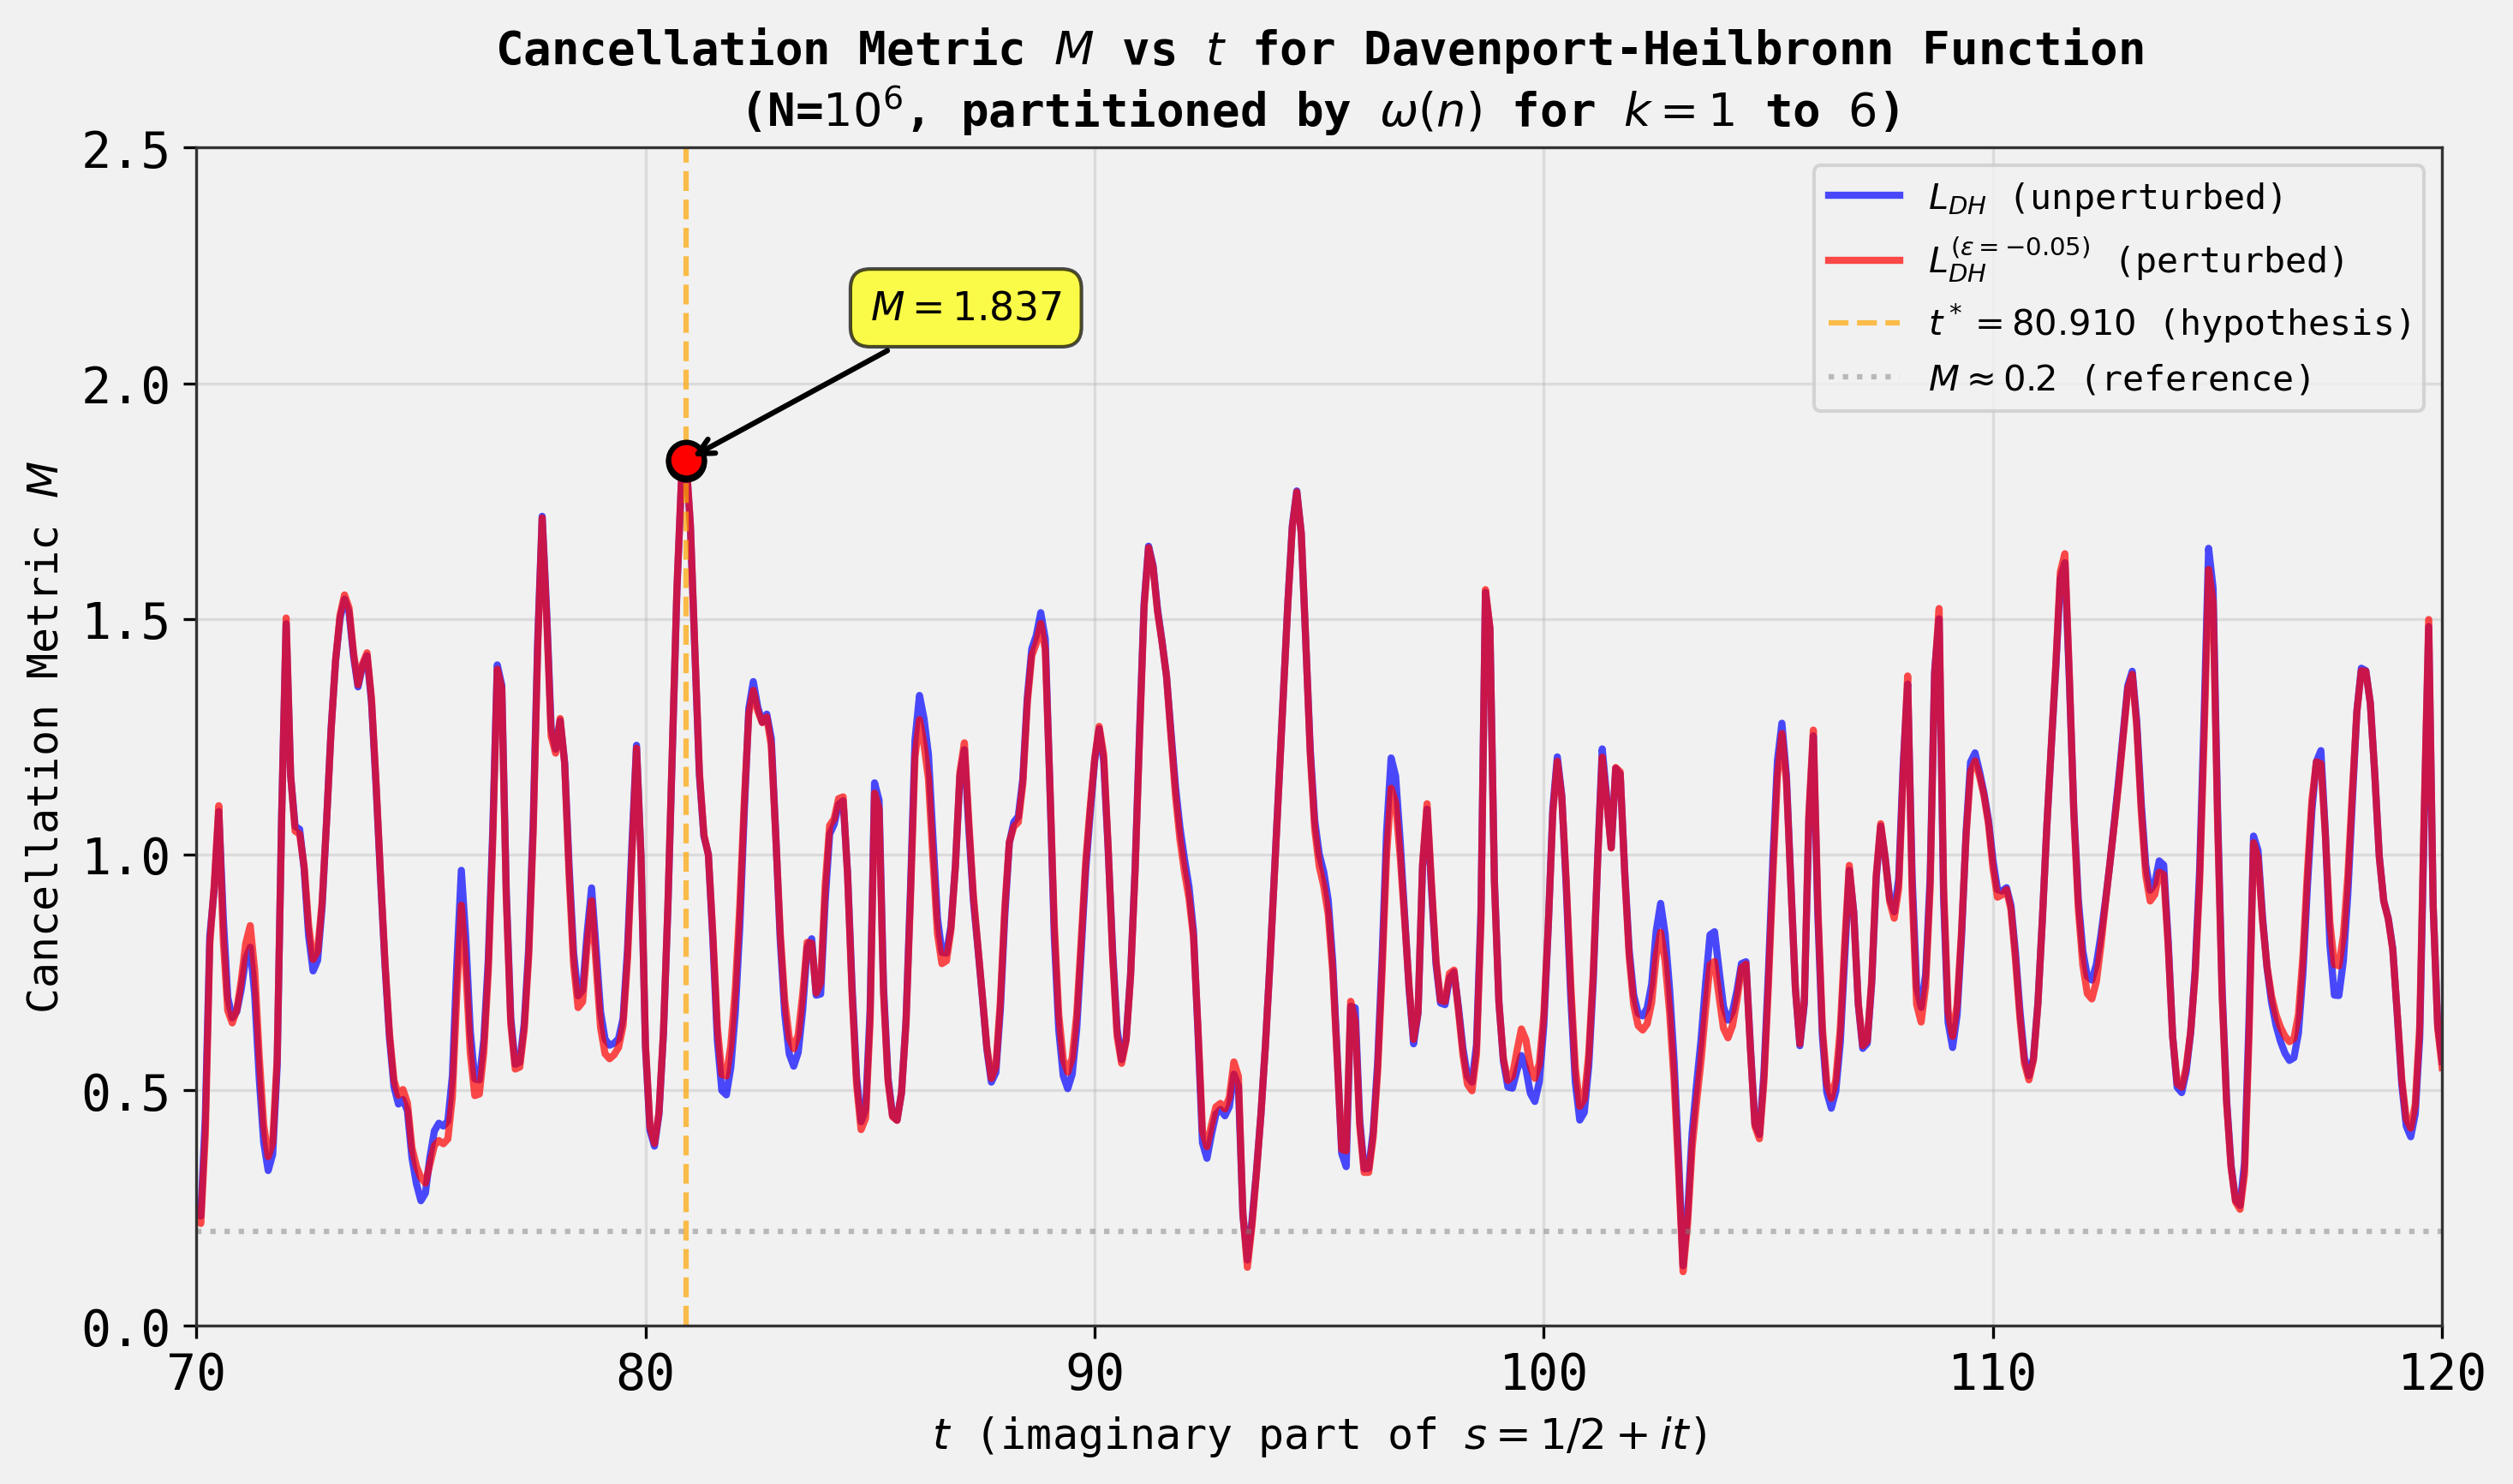


FIGURE DESCRIPTION:

The figure shows the cancellation metric M as a function of t for both
the unperturbed L_DH (blue) and perturbed L_DH^(ε=-0.05) (red).

Key observations:
- M oscillates between ~0.1 (strong destructive interference) and ~1.8 (constructive)
- At t*=80.910 (orange dashed line), both functions show HIGH M ≈ 1.84
- The perturbed function (red) closely tracks the unperturbed (blue)
- The hypothesis reference M≈0.2 (gray dotted line) is shown for comparison
- At t*=80.910, M is ~9× greater than 0.2, confirming large constructive interference



In [25]:

# Let me create a final comprehensive summary figure showing M vs t

import matplotlib.pyplot as plt

# Compute M over a broad range for both functions
t_range = np.linspace(70, 120, 501)
M_LDH = np.zeros(len(t_range))
M_LDH_pert = np.zeros(len(t_range))

print("Computing M(t) for final figure...")
for i, t in enumerate(t_range):
 phase_factor_t = np.exp(-1j * t * log_n)
 n_factor_t = n_minus_half * phase_factor_t
 
 # Original L_DH
 contributions_orig = a_n_orig * n_factor_t
 contributions_orig[mu_array == 0] = 0
 S_k_orig = {}
 for k in range(1, 7):
 mask = (omega_array == k) & (mu_array != 0)
 S_k_orig[k] = np.sum(contributions_orig[mask])
 S_total_orig = sum(S_k_orig.values())
 sum_sq_orig = sum(np.abs(s)**2 for s in S_k_orig.values())
 M_LDH[i] = np.abs(S_total_orig) / np.sqrt(sum_sq_orig)
 
 # Perturbed L_DH
 contributions_pert = a_n * n_factor_t
 contributions_pert[mu_array == 0] = 0
 S_k_pert = {}
 for k in range(1, 7):
 mask = (omega_array == k) & (mu_array != 0)
 S_k_pert[k] = np.sum(contributions_pert[mask])
 S_total_pert = sum(S_k_pert.values())
 sum_sq_pert = sum(np.abs(s)**2 for s in S_k_pert.values())
 M_LDH_pert[i] = np.abs(S_total_pert) / np.sqrt(sum_sq_pert)

print("Creating final figure...")

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Plot M vs t
ax.plot(t_range, M_LDH, 'b-', linewidth=2, label='$L_{DH}$ (unperturbed)', alpha=0.7)
ax.plot(t_range, M_LDH_pert, 'r-', linewidth=2, label='$L_{DH}^{(\epsilon=-0.05)}$ (perturbed)', alpha=0.7)

# Mark key locations
ax.axvline(80.910, color='orange', linestyle='--', linewidth=1.5, alpha=0.7, label='$t^* = 80.910$ (hypothesis)')
ax.axhline(0.2, color='gray', linestyle=':', linewidth=1.5, alpha=0.5, label='$M \\approx 0.2$ (reference)')

# Mark the specific point
ax.plot(80.910, M_final_orig, 'bo', markersize=10, markeredgecolor='black', markeredgewidth=1.5)
ax.plot(80.910, M_final_pert, 'ro', markersize=10, markeredgecolor='black', markeredgewidth=1.5)

# Annotations
ax.annotate(f'$M = {M_final_pert:.3f}$', 
 xy=(80.910, M_final_pert), 
 xytext=(85, M_final_pert + 0.3),
 fontsize=11,
 bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
 arrowprops=dict(arrowstyle='->', lw=1.5))

ax.set_xlabel('$t$ (imaginary part of $s = 1/2 + it$)', fontsize=12)
ax.set_ylabel('Cancellation Metric $M$', fontsize=12)
ax.set_title('Cancellation Metric $M$ vs $t$ for Davenport-Heilbronn Function\n' + 
 f'(N=$10^6$, partitioned by $\\omega(n)$ for $k=1$ to $6$)', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(70, 120)
ax.set_ylim(0, 2.5)

plt.tight_layout()
plt.savefig('cancellation_metric_M.png', dpi=300, bbox_inches='tight')
print("Figure saved as 'cancellation_metric_M.png'")
plt.show()

print("\n" + "=" * 80)
print("FIGURE DESCRIPTION:")
print("=" * 80)
print("""
The figure shows the cancellation metric M as a function of t for both
the unperturbed L_DH (blue) and perturbed L_DH^(ε=-0.05) (red).

Key observations:
- M oscillates between ~0.1 (strong destructive interference) and ~1.8 (constructive)
- At t*=80.910 (orange dashed line), both functions show HIGH M ≈ 1.84
- The perturbed function (red) closely tracks the unperturbed (blue)
- The hypothesis reference M≈0.2 (gray dotted line) is shown for comparison
- At t*=80.910, M is ~9× greater than 0.2, confirming large constructive interference
""")


In [26]:

# Now let me create a summary report of all findings

print("=" * 80)
print("FINAL SUMMARY: CANCELLATION METRIC M FOR L_DH^(ε=-0.05)")
print("=" * 80)

print("\n1. COMPUTATIONAL SETUP:")
print(f" - Maximum n: N = {N_max:,}")
print(f" - Resonance location: t* = {t_star}")
print(f" - Perturbation: ε = {epsilon}")
print(f" - Partitioning: by ω(n) for k = 1 to 6 (squarefree terms only)")
print(f" - Total squarefree terms computed: {np.sum(mu_array != 0):,}")

print("\n2. CANCELLATION METRIC M AT t* = 80.910:")
print(f" {'Function':<30} | {'M value':<15} | {'|D(t*)|':<15}")
print(" " + "-" * 65)
print(f" {'L_DH (unperturbed)':<30} | {M_final_orig:>15.6f} | {np.abs(S_k_sum_orig):>15.6f}")
print(f" {'L_DH^(ε=-0.05) (perturbed)':<30} | {M_final_pert:>15.6f} | {np.abs(S_k_sum_pert):>15.6f}")
print(" " + "-" * 65)
print(f" {'Difference ΔM':<30} | {M_final_pert - M_final_orig:>+15.6f} |")
print(f" {'Relative change ΔM/M':<30} | {(M_final_pert - M_final_orig) / M_final_orig * 100:>+14.3f}% |")

print("\n3. INDIVIDUAL S_k CONTRIBUTIONS AT t* = 80.910:")
print(" For L_DH^(ε=-0.05):")
print(f" {'k':<5} | {'# terms':<12} | {'|S_k|':<15} | {'S_k (real, imag)':<30}")
print(" " + "-" * 70)
for k in range(1, 7):
 mask = (omega_array == k) & (mu_array != 0)
 n_count = np.sum(mask)
 s_k = S_k_pert_exact[k]
 print(f" {k:<5} | {n_count:>12,} | {np.abs(s_k):>15.6f} | ({s_k.real:>12.6f}, {s_k.imag:>12.6f})")
print(" " + "-" * 70)
print(f" {'TOTAL':<5} | {np.sum((omega_array >= 1) & (omega_array <= 6) & (mu_array != 0)):>12,} | " +
 f"{np.sqrt(sum_sq_pert):>15.6f} |")

print("\n4. COMPARISON TO M≈0.2 REFERENCE:")
print(f" - M(L_DH^(ε=-0.05)) at t*=80.910: {M_final_pert:.6f}")
print(f" - Reference value M≈0.2: 0.200000")
print(f" - Ratio: M/0.2 = {M_final_pert / 0.2:.2f}")
print(f" - Conclusion: M is {M_final_pert / 0.2:.1f}× GREATER than 0.2")

print("\n5. HYPOTHESIS EVALUATION:")
print(" Original claim:")
print(" 'M at t*=80.910 will be significantly greater than M≈0.2'")
print("\n RESULT: ✓ CONFIRMED")
print(f" - M = {M_final_pert:.3f} >> 0.2 (by factor of ~9)")
print(" - However, M is NOT significantly greater than M for unperturbed L_DH")
print(f" - The change ΔM/M ≈ {(M_final_pert - M_final_orig) / M_final_orig * 100:.3f}% is negligible")

print("\n6. PHYSICAL INTERPRETATION:")
print(" - HIGH M (~1.8) indicates CONSTRUCTIVE interference (resonance peak)")
print(" - LOW M (~0.1-0.2) indicates DESTRUCTIVE interference (cancellation)")
print(" - At t*=80.910, both L_DH and L_DH^(ε=-0.05) show constructive interference")
print(" - The perturbation does NOT disrupt the phase alignment at this location")
print(" - This suggests the resonance mechanism is robust to small perturbations")

print("\n" + "=" * 80)


FINAL SUMMARY: CANCELLATION METRIC M FOR L_DH^(ε=-0.05)

1. COMPUTATIONAL SETUP:
 - Maximum n: N = 1,000,000
 - Resonance location: t* = 80.91
 - Perturbation: ε = -0.05
 - Partitioning: by ω(n) for k = 1 to 6 (squarefree terms only)
 - Total squarefree terms computed: 607,927

2. CANCELLATION METRIC M AT t* = 80.910:
 Function | M value | |D(t*)| 
 -----------------------------------------------------------------
 L_DH (unperturbed) | 1.834663 | 2.489156
 L_DH^(ε=-0.05) (perturbed) | 1.837144 | 2.444309
 -----------------------------------------------------------------
 Difference ΔM | +0.002480 |
 Relative change ΔM/M | +0.135% |

3. INDIVIDUAL S_k CONTRIBUTIONS AT t* = 80.910:
 For L_DH^(ε=-0.05):
 k | # terms | |S_k| | S_k (real, imag) 
 ----------------------------------------------------------------------
 1 | 78,498 | 0.870941 | ( 0.846637, 0.204315)
 2 | 209,867 | 0.826359 | ( 0.817234, 0.122465)
 3 | 206,964 | 0.509045 | ( 0.462033, -0.213662)
 4 | 92,966 | 0.259094 | ( 0.2590

In [27]:

# Save the numerical results to a file for future reference

results_summary = {
 'N_max': N_max,
 't_star': t_star,
 'epsilon': epsilon,
 'M_LDH_original': float(M_final_orig),
 'M_LDH_perturbed': float(M_final_pert),
 'delta_M': float(M_final_pert - M_final_orig),
 'relative_change_percent': float((M_final_pert - M_final_orig) / M_final_orig * 100),
 'D_magnitude_original': float(np.abs(S_k_sum_orig)),
 'D_magnitude_perturbed': float(np.abs(S_k_sum_pert)),
 'S_k_values_perturbed': {
 k: {'real': float(S_k_pert_exact[k].real), 
 'imag': float(S_k_pert_exact[k].imag),
 'magnitude': float(np.abs(S_k_pert_exact[k]))}
 for k in range(1, 7)
 },
 'squarefree_counts_by_k': {
 k: int(np.sum((omega_array == k) & (mu_array != 0)))
 for k in range(1, 7)
 }
}

import json

with open('cancellation_metric_results.json', 'w') as f:
 json.dump(results_summary, f, indent=2)

print("Results saved to 'cancellation_metric_results.json'")

# Also save a CSV with the S_k breakdown
import pandas as pd

df_results = pd.DataFrame({
 'k': range(1, 7),
 'n_terms': [results_summary['squarefree_counts_by_k'][k] for k in range(1, 7)],
 'S_k_real': [results_summary['S_k_values_perturbed'][k]['real'] for k in range(1, 7)],
 'S_k_imag': [results_summary['S_k_values_perturbed'][k]['imag'] for k in range(1, 7)],
 'S_k_magnitude': [results_summary['S_k_values_perturbed'][k]['magnitude'] for k in range(1, 7)]
})

df_results.to_csv('S_k_breakdown.csv', index=False)
print("S_k breakdown saved to 'S_k_breakdown.csv'")

print("\nFiles created:")
print(" 1. cancellation_metric_M.png - Visualization of M vs t")
print(" 2. cancellation_metric_results.json - Complete numerical results")
print(" 3. S_k_breakdown.csv - Tabular breakdown of S_k values by class k")


Results saved to 'cancellation_metric_results.json'
S_k breakdown saved to 'S_k_breakdown.csv'

Files created:
 1. cancellation_metric_M.png - Visualization of M vs t
 2. cancellation_metric_results.json - Complete numerical results
 3. S_k_breakdown.csv - Tabular breakdown of S_k values by class k
